In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df = pd.read_csv("Finance data.csv")
df.head()

,expense_id,department,category,amount,expense_date,approval_status,payment_method,budget_allocated,budget_used,vendor_name,expense_priority
0,EXP0001,Operations,Marketing Campaign,43931,2026-04-30,Approved,Cash,99113,89647,LinkedIn,Low
1,EXP0002,HR,Training,5062,2026-01-28,Rejected,Bank Transfer,297470,103058,Dell,Low
2,EXP0003,Engineering,Maintenance,32577,2025-12-09,Rejected,Bank Transfer,212198,62305,HP,High
3,EXP0004,Operations,Travel,36194,2025-02-14,Approved,UPI,143360,66144,Zoho,Low
4,EXP0005,Sales,Training,31707,2024-08-31,Approved,Cash,188952,121703,Oracle,High


In [3]:
print("===== DATA OVERVIEW =====")
print("\nTotal Records:", len(df))

===== DATA OVERVIEW =====

Total Records: 1000


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
expense_id          0
department          0
category            0
amount              0
expense_date        0
approval_status     0
payment_method      0
budget_allocated    0
budget_used         0
vendor_name         0
expense_priority    0
dtype: int64


In [5]:
print("\nDuplicate Records:", df.duplicated().sum())


Duplicate Records: 0


In [6]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   expense_id        1000 non-null   object
 1   department        1000 non-null   object
 2   category          1000 non-null   object
 3   amount            1000 non-null   int64 
 4   expense_date      1000 non-null   object
 5   approval_status   1000 non-null   object
 6   payment_method    1000 non-null   object
 7   budget_allocated  1000 non-null   int64 
 8   budget_used       1000 non-null   int64 
 9   vendor_name       1000 non-null   object
 10  expense_priority  1000 non-null   object
dtypes: int64(3), object(8)
memory usage: 86.1+ KB
None


In [7]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
             amount  budget_allocated    budget_used
count   1000.000000       1000.000000    1000.000000
mean   51124.136000     275746.024000  132634.574000
std    28690.178393     129852.157879  108788.298873
min     1393.000000      50509.000000    1101.000000
25%    26207.500000     166465.750000   47846.750000
50%    51522.000000     277924.000000   99029.000000
75%    76546.750000     387504.500000  190532.750000
max    99861.000000     499780.000000  493450.000000


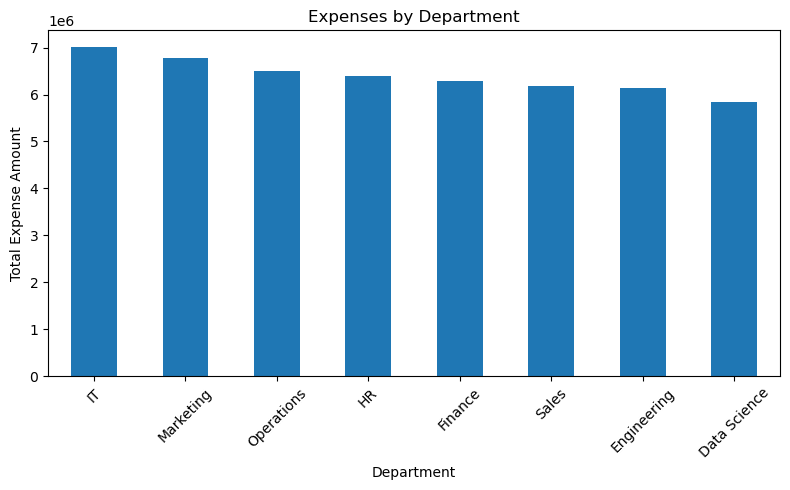

In [8]:
# -----------------------------------
# 2. EXPENSES BY DEPARTMENT
# -----------------------------------

dept_expense = df.groupby('department')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
dept_expense.plot(kind='bar')
plt.title("Expenses by Department")
plt.xlabel("Department")
plt.ylabel("Total Expense Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

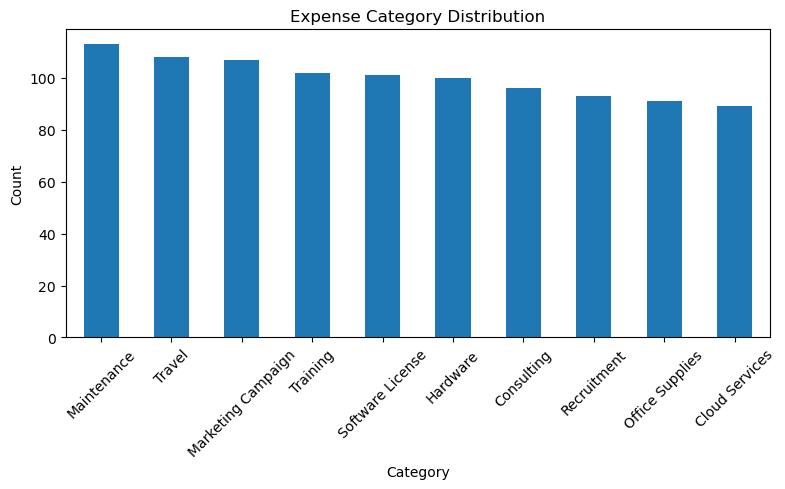

In [9]:
# -----------------------------------
# 3. EXPENSE CATEGORY DISTRIBUTION
# -----------------------------------

category_expense = df['category'].value_counts()

plt.figure(figsize=(8,5))
category_expense.plot(kind='bar')
plt.title("Expense Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

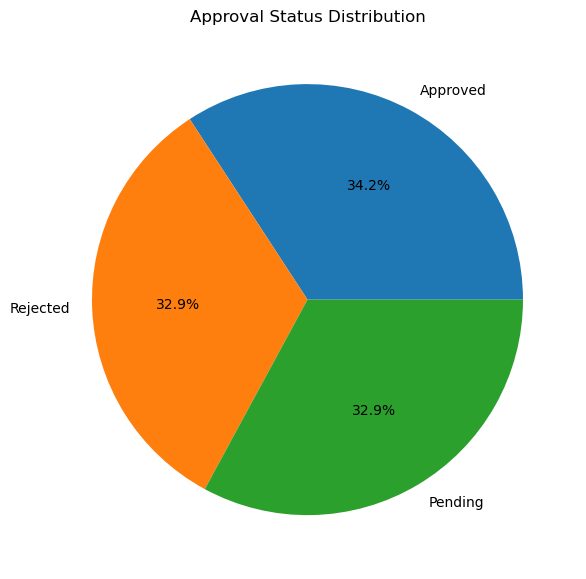

In [10]:
# -----------------------------------
# 4. APPROVAL STATUS DISTRIBUTION
# -----------------------------------

approval_status = df['approval_status'].value_counts()

plt.figure(figsize=(6,6))
approval_status.plot(kind='pie', autopct='%1.1f%%')
plt.title("Approval Status Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

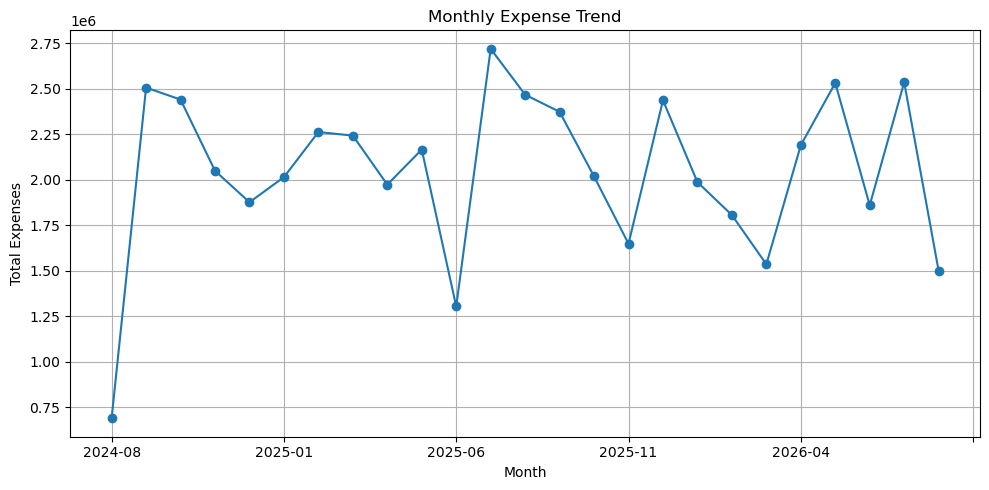

In [11]:
# -----------------------------------
# 5. MONTHLY EXPENSE TREND
# -----------------------------------

df['expense_date'] = pd.to_datetime(df['expense_date'])

monthly_expense = (
    df.groupby(df['expense_date'].dt.to_period('M'))['amount']
      .sum()
)

monthly_expense.index = monthly_expense.index.astype(str)

plt.figure(figsize=(10,5))
monthly_expense.plot(kind='line', marker='o')
plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Total Expenses")
plt.grid(True)
plt.tight_layout()
plt.show()

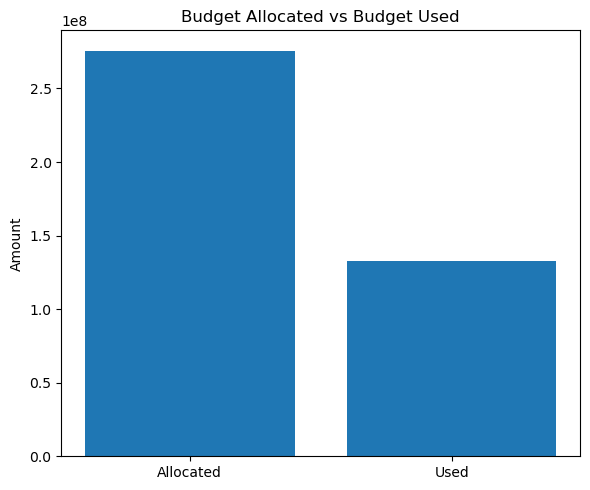

In [12]:
# -----------------------------------
# 6. BUDGET ALLOCATED VS BUDGET USED
# -----------------------------------

budget_data = {
    "Allocated": df['budget_allocated'].sum(),
    "Used": df['budget_used'].sum()
}

plt.figure(figsize=(6,5))
plt.bar(budget_data.keys(), budget_data.values())
plt.title("Budget Allocated vs Budget Used")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


In [13]:
# -----------------------------------
# 7. BUSINESS INSIGHTS
# -----------------------------------

print("\n===== BUSINESS INSIGHTS =====")

highest_dept = dept_expense.idxmax()
highest_dept_value = dept_expense.max()

print(f"1. Highest spending department: {highest_dept} ({highest_dept_value:.2f})")

top_category = category_expense.idxmax()
print(f"2. Most common expense category: {top_category}")

approved_pct = round(
    (df['approval_status'] == 'Approved').mean() * 100,
    2
)
print(f"3. Approval rate: {approved_pct}%")

budget_utilization = round(
    (df['budget_used'].sum() /
     df['budget_allocated'].sum()) * 100,
    2
)
print(f"4. Overall budget utilization: {budget_utilization}%")

print("5. Monthly expense trend chart shows spending patterns over time.")


===== BUSINESS INSIGHTS =====
1. Highest spending department: IT (7016380.00)
2. Most common expense category: Maintenance
3. Approval rate: 34.2%
4. Overall budget utilization: 48.1%
5. Monthly expense trend chart shows spending patterns over time.
